# 07 · Trunk Fit & Dijkstra Branch Graph

**Goal:** turn the filtered point cloud into a structured branch graph
rooted at the trunk base. Implemented from scratch in `src/trunk.py` and
`src/branch_graph.py`.

Pipeline:
1. **`trunk.ransac_trunk_axis`** — RANSAC 3D line fit with a near-vertical
   prior; refit best inlier set by PCA; pick root as the inlier with the
   smallest signed projection on the axis (trunk base).
2. **`branch_graph.extract_branch_graph`** — kNN adjacency → Dijkstra
   shortest-path tree from the trunk root → spur pruning → collinear
   segment merging. The shortest-path tree IS the branching structure
   because real trees never rejoin themselves (no cycles in the canopy).


In [1]:
# Standard preamble.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline


## 0. Load the filtered cloud (output of notebook 06)

In [2]:
from src import sfm, trunk, branch_graph, viz

TREE_ID = "tree_5"

FILTERED_PLY = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_filtered.ply"
if not FILTERED_PLY.exists():
    raise FileNotFoundError(
        f"Filtered cloud not found at {FILTERED_PLY}. Run notebook 06 first."
    )

points, _ = sfm.load_ply(FILTERED_PLY)
print(f"Loaded {len(points)} filtered points from {FILTERED_PLY.name}")


Loaded 22261 filtered points from tree_5_filtered.ply


## 1. Fit the trunk axis (RANSAC + PCA refit)

`vertical_axis=2` assumes Z is up. If your COLMAP orientation ended up
with Y or X as the up axis, change accordingly — the most reliable way
to find which axis is up is to render the cloud and pick the axis along
which the trunk is longest.


In [3]:
fit = trunk.ransac_trunk_axis(
    points,
    num_iter=2000,
    inlier_thresh=0.05,
    vertical_prior=True,
    vertical_axis=2,         # change to 0 or 1 if your scene's up axis differs
    vertical_cos_min=0.7,    # require |dot(direction, up_axis)| >= 0.7
    rng=np.random.default_rng(131),
)
n_inliers = int(fit.inlier_mask.sum())
print(f"Trunk inliers: {n_inliers} / {len(points)}  ({100*n_inliers/len(points):.1f}%)")
print(f"Mean inlier perp distance: {fit.inlier_distance_mean*100:.2f} cm")
print(f"Trunk root: {fit.root}")
print(f"Direction:  {fit.direction}")
print(f"Trunk height (extent of inliers along axis): {trunk.trunk_height(fit, points):.2f}")


Trunk inliers: 842 / 22261  (3.8%)
Mean inlier perp distance: 2.96 cm
Trunk root: [-1.6630193   2.89952462  2.63679687]
Direction:  [ 0.11254757 -0.53512207  0.83724394]
Trunk height (extent of inliers along axis): 9.56


## 2. Extract the branch graph

`extract_branch_graph` glues together kNN graph construction, Dijkstra
from the trunk root, spur pruning, and collinear segment merging. The
result is a tree-shaped graph where each edge corresponds to a branch
segment.


In [4]:
graph = branch_graph.extract_branch_graph(
    points,
    trunk_root_xyz=fit.root,
    k=12,
    max_edge_length=2.0,         # tune to your scene scale (metres if COLMAP is metric)
    min_spur_length=0.30,
    collinear_tolerance_deg=12.0,
)
print(f"Skeleton: {len(graph.nodes)} nodes, {len(graph.edges)} edges after pruning + merging")


Skeleton: 4970 nodes, 4969 edges after pruning + merging


## 3. Visualise — branch graph overlaid on the trunk axis

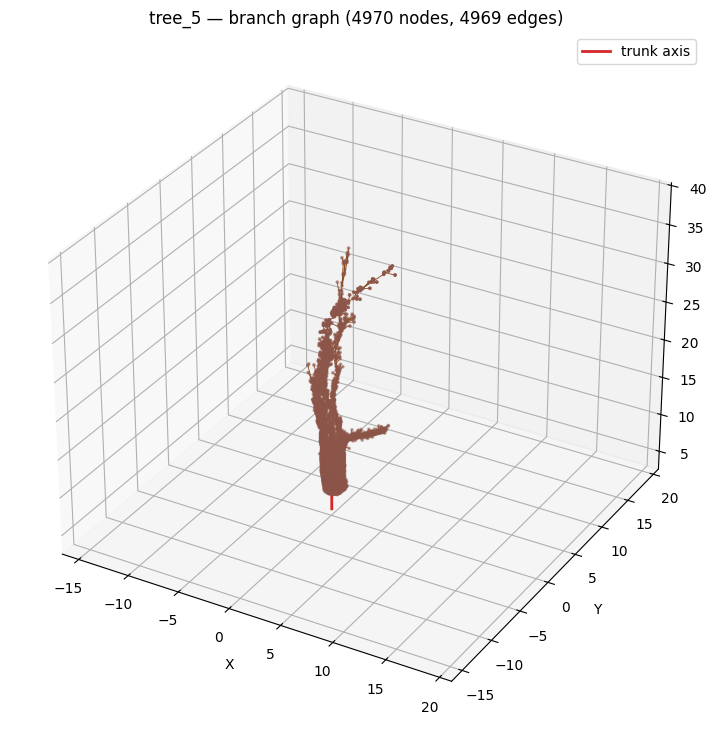

In [5]:
fig = viz.plot_branch_graph(
    graph.nodes, graph.edges,
    trunk_axis=(fit.root, fit.direction),
    title=f"{TREE_ID} — branch graph "
          f"({len(graph.nodes)} nodes, {len(graph.edges)} edges)",
)
viz.save_fig(fig, f"07_{TREE_ID}_branch_graph.png")
plt.show()


## 4. Persist the graph for evaluation (notebook 08)

In [6]:
out = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_graph.npz"
np.savez(
    out,
    nodes=graph.nodes,
    edges=np.array(graph.edges, dtype=np.int64),
    trunk_root=fit.root,
    trunk_direction=fit.direction,
    parents=np.array(list(graph.parent_of.items()), dtype=np.int64),
    distances=graph.distances,
)
print(f"Saved branch graph → {out}")


Saved branch graph → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_graph.npz
